# Triplet Loss

В этом ноутбуке я реализую обучение модели распознавания лиц с помощью **Triplet Loss**.

В отличие от CrossEntropy и ArcFace, здесь модели не нужен классификационный слой. Модель напрямую учится строить эмбеддинги так, чтобы фотографии одного человека были близко друг к другу, а фотографии разных людей были дальше друг от друга.

## Идея Triplet Loss

Для обучения используются тройки изображений:

- `anchor` — исходное изображение лица;
- `positive` — другое фото того же человека;
- `negative` — фото другого человека.

Формула:

$$L(a, p, n) = max(d(a, p) - d(a, n) + margin, 0)$$

Здесь `d(a, p)` — расстояние между anchor и positive, а `d(a, n)` — расстояние между anchor и negative.

Я использую косинусное расстояние:

```text
cosine_distance(x, y) = 1 - cosine_similarity(x, y)
```

Перед подсчётом расстояний embeddings нормализуются.

## Метрики качества

- `triplet_acc` — доля троек, где `d(anchor, positive) < d(anchor, negative)`;
- `same_person_mean` — средний cosine similarity для фото одного человека;
- `different_people_mean` — средний cosine similarity для фото разных людей;
- `gap` — разница между ними (чем больше `gap`, тем лучше embeddings разделяют людей)

# Импорты

In [1]:
from pathlib import Path
from itertools import combinations
import random
import math
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Загрузка данных

In [3]:
PROJECT_DIR = Path("/content/celeba")

ALIGNED_CSV = PROJECT_DIR / "aligned_faces_predicted.csv"
PRED_DIR = PROJECT_DIR / "pred"
PRED_ZIP = PRED_DIR / "pred.zip"

CE_WEIGHTS = PROJECT_DIR / "ce_efficientnet_b0_best.pt"
ARCFACE_WEIGHTS = PROJECT_DIR / "arcface_efficientnet_b0_best.pt"
TRIPLET_WEIGHTS = PROJECT_DIR / "triplet_efficientnet_b0_best.pt"

In [4]:
PRED_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(PRED_ZIP, "r") as zip_ref:
    zip_ref.extractall(PRED_DIR)

In [5]:
df = pd.read_csv(ALIGNED_CSV)
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,lefteye_x_pred,lefteye_y_pred,righteye_x_pred,righteye_y_pred,nose_x_pred,nose_y_pred,leftmouth_x_pred,leftmouth_y_pred,rightmouth_x_pred,rightmouth_y_pred
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,40.0,46.0,86.0,44.0,58.0,72.0,54.0,82.0,98.0,78.0
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,40.0,46.0,86.0,46.0,54.0,68.0,42.0,82.0,88.0,82.0
2,000015.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,40.0,46.0,84.0,40.0,72.0,62.0,56.0,82.0,94.0,74.0
3,000018.jpg,-1,1,-1,-1,-1,-1,-1,1,-1,...,40.0,46.0,94.0,48.0,64.0,68.0,38.0,82.0,90.0,84.0
4,000088.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,40.0,46.0,76.0,40.0,54.0,62.0,54.0,78.0,78.0,74.0


В моём ноутбуке с ArcFace путь к папке с выровненными лицами немного поменялся, поэтому поправляю его:

In [6]:
old_root = "/content/celeba/prepared_data/aligned_faces/pred"
new_root = "/content/celeba/pred"

In [7]:
if "aligned_path" in df.columns:
    df["aligned_path"] = df["aligned_path"].astype(str).str.replace(
        old_root,
        new_root,
        regex=False,
    )

df["file_exists"] = df["aligned_path"].apply(lambda path: Path(path).exists())

In [8]:
print("Всего изображений:", len(df))
print("Файлы найдены:", int(df["file_exists"].sum()))
print("Число людей:", df["identity_id"].nunique())

Всего изображений: 15017
Файлы найдены: 15017
Число людей: 500


In [9]:
df = df[df["file_exists"]].copy().reset_index(drop=True)

# LabelEncoder и train/val split

In [10]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["identity_id"])

num_classes = df["label"].nunique()

print("Число изображений:", len(df))
print("Число классов:", num_classes)
print(df["label"].value_counts().describe())

Число изображений: 15017
Число классов: 500
count    500.000000
mean      30.034000
std        0.324121
min       30.000000
25%       30.000000
50%       30.000000
75%       30.000000
max       35.000000
Name: count, dtype: float64


In [11]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(train_df.shape, val_df.shape)
print("train classes:", train_df["label"].nunique())
print("val classes:", val_df["label"].nunique())

(12013, 81) (3004, 81)
train classes: 500
val classes: 500


# Transforms

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )
    ], p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Dataset для Triplet Loss

Для Triplet Loss нужен Dataset, который возвращает сразу три картинки:
`anchor`, `positive`, `negative`.

`positive` берётся из того же класса, что и `anchor`. `negative` берётся из другого класса.

In [13]:
class TripletFaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.labels = self.df["label"].to_numpy()

        self.label_to_indices = {}
        for index, label in enumerate(self.labels):
            self.label_to_indices.setdefault(label, []).append(index)

        self.unique_labels = np.array(sorted(self.label_to_indices.keys()))

    def __len__(self):
        return len(self.df)

    def _load_image(self, index):
        image_path = self.df.iloc[index]["aligned_path"]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image

    def __getitem__(self, index):
        anchor_label = self.labels[index]

        positive_candidates = self.label_to_indices[anchor_label]

        positive_index = index
        while positive_index == index:
            positive_index = random.choice(positive_candidates)

        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = int(random.choice(self.unique_labels))

        negative_index = random.choice(self.label_to_indices[negative_label])

        anchor = self._load_image(index)
        positive = self._load_image(positive_index)
        negative = self._load_image(negative_index)

        return anchor, positive, negative, torch.tensor(anchor_label, dtype=torch.long)

In [34]:
batch_size = 16

train_triplet_dataset = TripletFaceDataset(train_df, transform=train_transform)
val_triplet_dataset = TripletFaceDataset(val_df, transform=val_transform)

In [35]:
train_triplet_loader = DataLoader(
    train_triplet_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_triplet_loader = DataLoader(
    val_triplet_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [36]:
anchor, positive, negative, labels = next(iter(train_triplet_loader))

anchor.shape, positive.shape, negative.shape, labels.shape

(torch.Size([16, 3, 224, 224]),
 torch.Size([16, 3, 224, 224]),
 torch.Size([16, 3, 224, 224]),
 torch.Size([16]))

# Модель эмбеддингов

In [17]:
class EfficientNetEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()

        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        backbone = efficientnet_b0(weights=weights)

        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim, bias=False),
            nn.BatchNorm1d(embedding_dim),
            nn.Dropout(p=0.3),
        )

    def forward(self, x):
        x = self.backbone(x)
        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)
        return emb

Для стабильности беру старт из уже обученной CE-модели EfficientNet-B0. Дальше я дообучаю embedding-модель уже с Triplet Loss.

In [18]:
class EfficientNetClassifierCE(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, pretrained=True):
        super().__init__()

        self.embedding_model = EfficientNetEmbeddingModel(
            embedding_dim=embedding_dim,
            pretrained=pretrained,
        )

        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        emb = self.embedding_model(x)
        logits = self.classifier(emb)
        return logits

In [19]:
use_imagenet_start = not CE_WEIGHTS.exists()

triplet_model = EfficientNetEmbeddingModel(
    embedding_dim=512,
    pretrained=use_imagenet_start,
).to(device)

ce_state = torch.load(CE_WEIGHTS, map_location=device)

if isinstance(ce_state, dict) and "state_dict" in ce_state:
    ce_state = ce_state["state_dict"]

embedding_prefix = "embedding_model."
embedding_state = {
    key[len(embedding_prefix):]: value
    for key, value in ce_state.items()
    if key.startswith(embedding_prefix)
}

triplet_model.load_state_dict(embedding_state, strict=True)

<All keys matched successfully>

# Triplet Loss

## Функция triplet_loss

In [20]:
def triplet_loss(anchor_embeddings, positive_embeddings, negative_embeddings, margin=0.2):
    positive_distance = 1.0 - F.cosine_similarity(anchor_embeddings, positive_embeddings)
    negative_distance = 1.0 - F.cosine_similarity(anchor_embeddings, negative_embeddings)

    losses = F.relu(positive_distance - negative_distance + margin)

    return losses.mean(), positive_distance.mean().item(), negative_distance.mean().item()

Проверяю на искусственном примере, что loss уменьшается, когда positive ближе anchor, чем negative.

In [32]:
test_anchor = F.normalize(torch.tensor([[1.0, 0.0], [1.0, 0.0]]), p=2, dim=1)
test_positive = F.normalize(torch.tensor([[0.9, 0.1], [0.0, 1.0]]), p=2, dim=1)
test_negative = F.normalize(torch.tensor([[0.0, 1.0], [0.9, 0.1]]), p=2, dim=1)

test_loss, test_pos_dist, test_neg_dist = triplet_loss(
    test_anchor,
    test_positive,
    test_negative,
    margin=0.2,
)

In [33]:
print("test loss:", test_loss.item())
print("mean positive distance:", test_pos_dist)
print("mean negative distance:", test_neg_dist)

assert test_loss.item() > 0

test loss: 0.5969418883323669
mean positive distance: 0.503058135509491
mean negative distance: 0.503058135509491


## Функции обучения и валидации

In [22]:
def triplet_accuracy(anchor_embeddings, positive_embeddings, negative_embeddings):
    positive_distance = 1.0 - F.cosine_similarity(anchor_embeddings, positive_embeddings)
    negative_distance = 1.0 - F.cosine_similarity(anchor_embeddings, negative_embeddings)

    return (positive_distance < negative_distance).float().mean().item()

In [23]:
def train_one_epoch_triplet(model, loader, optimizer, device, margin=0.2):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_pos_dist = 0.0
    total_neg_dist = 0.0
    total_count = 0

    for anchor, positive, negative, _ in tqdm(loader):
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        anchor_embeddings = model(anchor)
        positive_embeddings = model(positive)
        negative_embeddings = model(negative)

        loss, pos_dist, neg_dist = triplet_loss(
            anchor_embeddings,
            positive_embeddings,
            negative_embeddings,
            margin=margin,
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        batch_size = anchor.size(0)
        acc = triplet_accuracy(anchor_embeddings, positive_embeddings, negative_embeddings)

        total_loss += loss.item() * batch_size
        total_acc += acc * batch_size
        total_pos_dist += pos_dist * batch_size
        total_neg_dist += neg_dist * batch_size
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "triplet_acc": total_acc / total_count,
        "pos_dist": total_pos_dist / total_count,
        "neg_dist": total_neg_dist / total_count,
    }

In [24]:
@torch.no_grad()
def evaluate_triplet(model, loader, device, margin=0.2):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_pos_dist = 0.0
    total_neg_dist = 0.0
    total_count = 0

    for anchor, positive, negative, _ in tqdm(loader):
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        anchor_embeddings = model(anchor)
        positive_embeddings = model(positive)
        negative_embeddings = model(negative)

        loss, pos_dist, neg_dist = triplet_loss(
            anchor_embeddings,
            positive_embeddings,
            negative_embeddings,
            margin=margin,
        )

        batch_size = anchor.size(0)
        acc = triplet_accuracy(anchor_embeddings, positive_embeddings, negative_embeddings)

        total_loss += loss.item() * batch_size
        total_acc += acc * batch_size
        total_pos_dist += pos_dist * batch_size
        total_neg_dist += neg_dist * batch_size
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "triplet_acc": total_acc / total_count,
        "pos_dist": total_pos_dist / total_count,
        "neg_dist": total_neg_dist / total_count,
    }

## Обучение Triplet Loss


In [30]:
margin = 0.2
num_epochs_triplet = 12

optimizer_triplet = torch.optim.AdamW(
    triplet_model.parameters(),
    lr=3e-5,
    weight_decay=1e-3,
)

scheduler_triplet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_triplet,
    mode="max",
    factor=0.5,
    patience=2,
)

history_triplet = {
    "train_loss": [],
    "train_triplet_acc": [],
    "train_pos_dist": [],
    "train_neg_dist": [],
    "val_loss": [],
    "val_triplet_acc": [],
    "val_pos_dist": [],
    "val_neg_dist": [],
}

best_val_triplet_acc = 0.0

In [31]:
import gc

for variable_name in [
    "ce_model",
    "arc_model",
    "ce_eval_model",
    "arc_eval_model",
    "recognition_model",
    "landmark_model",
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()
torch.cuda.empty_cache()

In [37]:
for epoch in range(1, num_epochs_triplet + 1):
    train_metrics = train_one_epoch_triplet(
        triplet_model,
        train_triplet_loader,
        optimizer_triplet,
        device,
        margin=margin,
    )

    val_metrics = evaluate_triplet(
        triplet_model,
        val_triplet_loader,
        device,
        margin=margin,
    )

    scheduler_triplet.step(val_metrics["triplet_acc"])

    history_triplet["train_loss"].append(train_metrics["loss"])
    history_triplet["train_triplet_acc"].append(train_metrics["triplet_acc"])
    history_triplet["train_pos_dist"].append(train_metrics["pos_dist"])
    history_triplet["train_neg_dist"].append(train_metrics["neg_dist"])

    history_triplet["val_loss"].append(val_metrics["loss"])
    history_triplet["val_triplet_acc"].append(val_metrics["triplet_acc"])
    history_triplet["val_pos_dist"].append(val_metrics["pos_dist"])
    history_triplet["val_neg_dist"].append(val_metrics["neg_dist"])

    print(
        f"Epoch {epoch:02d}/{num_epochs_triplet} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_triplet_acc={train_metrics['triplet_acc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_triplet_acc={val_metrics['triplet_acc']:.4f} | "
        f"val_pos_dist={val_metrics['pos_dist']:.4f} | "
        f"val_neg_dist={val_metrics['neg_dist']:.4f}"
    )

    if val_metrics["triplet_acc"] > best_val_triplet_acc:
        best_val_triplet_acc = val_metrics["triplet_acc"]
        torch.save(triplet_model.state_dict(), TRIPLET_WEIGHTS)

100%|██████████| 188/188 [00:24<00:00,  7.74it/s]


Epoch 01/12 | train_loss=0.0157 | train_triplet_acc=0.9918 | val_loss=0.0211 | val_triplet_acc=0.9644 | val_pos_dist=0.5720 | val_neg_dist=0.9930


100%|██████████| 188/188 [00:26<00:00,  7.07it/s]


Epoch 02/12 | train_loss=0.0129 | train_triplet_acc=0.9904 | val_loss=0.0212 | val_triplet_acc=0.9640 | val_pos_dist=0.5534 | val_neg_dist=0.9951


100%|██████████| 188/188 [00:25<00:00,  7.34it/s]


...

Epoch 10/12 | train_loss=0.0085 | train_triplet_acc=0.9943 | val_loss=0.0155 | val_triplet_acc=0.9754 | val_pos_dist=0.4967 | val_neg_dist=0.9921


100%|██████████| 188/188 [00:24<00:00,  7.55it/s]


Epoch 11/12 | train_loss=0.0082 | train_triplet_acc=0.9928 | val_loss=0.0154 | val_triplet_acc=0.9740 | val_pos_dist=0.4923 | val_neg_dist=0.9931


100%|██████████| 188/188 [00:24<00:00,  7.60it/s]

Epoch 12/12 | train_loss=0.0072 | train_triplet_acc=0.9960 | val_loss=0.0179 | val_triplet_acc=0.9644 | val_pos_dist=0.4935 | val_neg_dist=0.9912


## Графики обучения

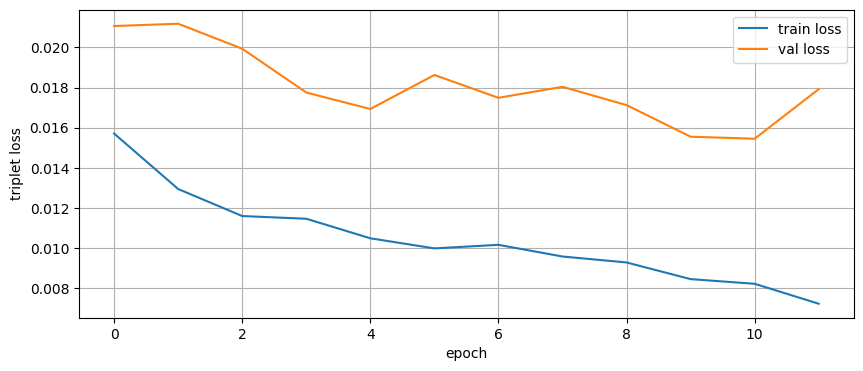

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(history_triplet["train_loss"], label="train loss")
plt.plot(history_triplet["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("triplet loss")
plt.legend()
plt.grid()
plt.show()

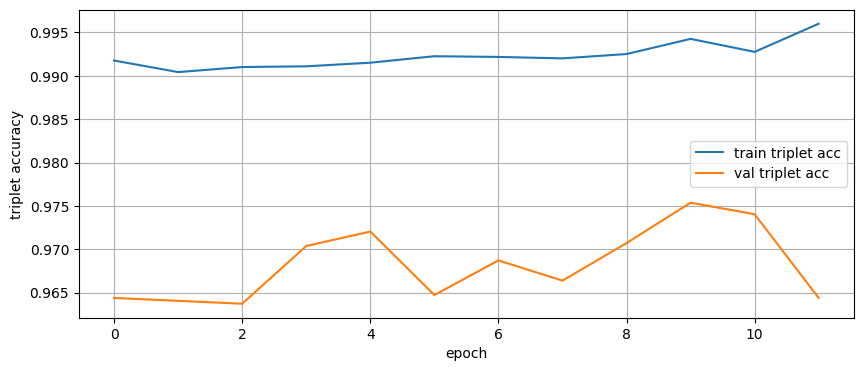

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(history_triplet["train_triplet_acc"], label="train triplet acc")
plt.plot(history_triplet["val_triplet_acc"], label="val triplet acc")
plt.xlabel("epoch")
plt.ylabel("triplet accuracy")
plt.legend()
plt.grid()
plt.show()

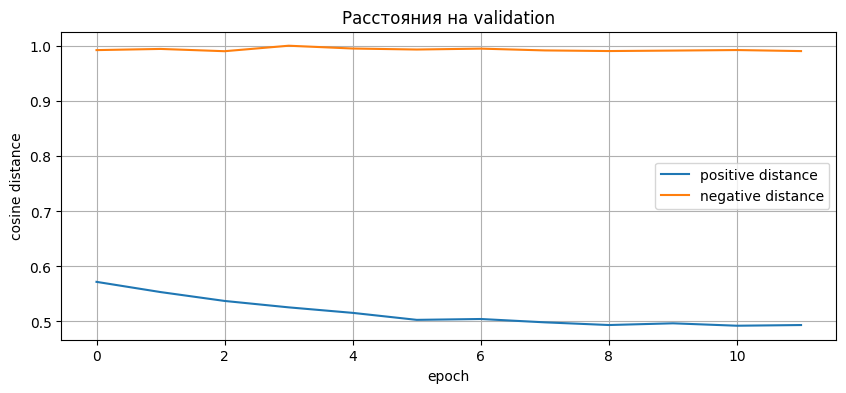

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(history_triplet["val_pos_dist"], label="positive distance")
plt.plot(history_triplet["val_neg_dist"], label="negative distance")
plt.xlabel("epoch")
plt.ylabel("cosine distance")
plt.title("Расстояния на validation")
plt.legend()
plt.grid()
plt.show()

# Оценка эмбеддингов через cosine similarity и сравнение моделей

Теперь сравню эмбеддинги для пар, где один человек и где разные людм:

In [41]:
class FaceRecognitionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["aligned_path"]).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, label

In [42]:
val_dataset = FaceRecognitionDataset(val_df, transform=val_transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [43]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()

    all_embeddings = []
    all_labels = []

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)

        if hasattr(model, "embedding_model"):
            embeddings = model.embedding_model(imgs)
        else:
            embeddings = model(imgs)

        embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels)

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return all_embeddings, all_labels

In [44]:
best_triplet_model = EfficientNetEmbeddingModel(
    embedding_dim=512,
    pretrained=False,
).to(device)

best_triplet_model.load_state_dict(
    torch.load(TRIPLET_WEIGHTS, map_location=device),
    strict=True,
)

best_triplet_model.eval()

EfficientNetEmbeddingModel(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
      

Сравнение с CE и ArcFace

In [45]:
class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.2):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weights = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embeddings, weights)
        sine = torch.sqrt(torch.clamp(1.0 - cosine ** 2, min=1e-7))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = one_hot * phi + (1.0 - one_hot) * cosine
        logits *= self.s

        return logits

In [46]:
class EfficientNetClassifierArcFace(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, pretrained=False):
        super().__init__()

        self.embedding_model = EfficientNetEmbeddingModel(
            embedding_dim=embedding_dim,
            pretrained=pretrained,
        )

        self.arcface = ArcFaceLayer(
            in_features=embedding_dim,
            out_features=num_classes,
            s=30.0,
            m=0.2,
        )

    def forward(self, x, labels=None):
        embeddings = self.embedding_model(x)

        if labels is None:
            return embeddings

        logits = self.arcface(embeddings, labels)
        return logits

In [47]:
ce_eval_model = EfficientNetClassifierCE(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=False,
).to(device)

ce_eval_model.load_state_dict(
    torch.load(CE_WEIGHTS, map_location=device),
    strict=True,
)
ce_eval_model.eval()

EfficientNetClassifierCE(
  (embedding_model): EfficientNetEmbeddingModel(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, ker

In [48]:
arc_eval_model = EfficientNetClassifierArcFace(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=False,
).to(device)

arc_eval_model.load_state_dict(
    torch.load(ARCFACE_WEIGHTS, map_location=device),
    strict=True,
)
arc_eval_model.eval()

EfficientNetClassifierArcFace(
  (embedding_model): EfficientNetEmbeddingModel(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32

In [49]:
ce_embeddings, val_labels = extract_embeddings(ce_eval_model, val_loader, device)
arc_embeddings, _ = extract_embeddings(arc_eval_model, val_loader, device)
triplet_embeddings, _ = extract_embeddings(best_triplet_model, val_loader, device)

100%|██████████| 188/188 [00:08<00:00, 21.41it/s]


In [50]:
def make_verification_pairs(labels, max_positive_pairs=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)

    label_to_indices = {}
    for index, label in enumerate(labels):
        label_to_indices.setdefault(label, []).append(index)

    positive_pairs = []

    for label, indices in label_to_indices.items():
        if len(indices) >= 2:
            positive_pairs.extend(list(combinations(indices, 2)))

    positive_pairs = np.array(positive_pairs)

    if len(positive_pairs) > max_positive_pairs:
        selected = rng.choice(len(positive_pairs), size=max_positive_pairs, replace=False)
        positive_pairs = positive_pairs[selected]

    negative_pairs = []

    while len(negative_pairs) < len(positive_pairs):
        i, j = rng.choice(len(labels), size=2, replace=False)

        if labels[i] != labels[j]:
            negative_pairs.append((i, j))

    negative_pairs = np.array(negative_pairs)

    pairs = np.concatenate([positive_pairs, negative_pairs], axis=0)
    pair_labels = np.concatenate([
        np.ones(len(positive_pairs)),
        np.zeros(len(negative_pairs)),
    ])

    return pairs, pair_labels

In [51]:
pairs, pair_labels = make_verification_pairs(val_labels)
print("positive pairs:", int(pair_labels.sum()))
print("negative pairs:", int((1 - pair_labels).sum()))

positive pairs: 3000
negative pairs: 3000


In [52]:
def evaluate_embedding_quality(embeddings, pairs, pair_labels):
    similarities = []

    for i, j in pairs:
        sim = F.cosine_similarity(
            embeddings[i].unsqueeze(0),
            embeddings[j].unsqueeze(0),
        ).item()
        similarities.append(sim)

    similarities = np.array(similarities)

    same_scores = similarities[pair_labels == 1]
    different_scores = similarities[pair_labels == 0]

    threshold_candidates = np.linspace(similarities.min(), similarities.max(), 200)
    best_accuracy = 0.0
    best_threshold = 0.0

    for threshold in threshold_candidates:
        predictions = similarities >= threshold
        accuracy = (predictions == pair_labels).mean()

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return {
        "similarities": similarities,
        "same_mean": same_scores.mean(),
        "different_mean": different_scores.mean(),
        "gap": same_scores.mean() - different_scores.mean(),
        "best_threshold": best_threshold,
        "best_accuracy": best_accuracy,
    }

In [53]:
ce_quality = evaluate_embedding_quality(ce_embeddings, pairs, pair_labels)
arc_quality = evaluate_embedding_quality(arc_embeddings, pairs, pair_labels)
triplet_quality = evaluate_embedding_quality(triplet_embeddings, pairs, pair_labels)

In [54]:
quality_df = pd.DataFrame([
    {
        "model": "EfficientNet-B0 CE",
        "same_person_cosine": ce_quality["same_mean"],
        "different_people_cosine": ce_quality["different_mean"],
        "gap": ce_quality["gap"],
        "verification_accuracy": ce_quality["best_accuracy"],
    },
    {
        "model": "EfficientNet-B0 ArcFace",
        "same_person_cosine": arc_quality["same_mean"],
        "different_people_cosine": arc_quality["different_mean"],
        "gap": arc_quality["gap"],
        "verification_accuracy": arc_quality["best_accuracy"],
    },
    {
        "model": "EfficientNet-B0 Triplet",
        "same_person_cosine": triplet_quality["same_mean"],
        "different_people_cosine": triplet_quality["different_mean"],
        "gap": triplet_quality["gap"],
        "verification_accuracy": triplet_quality["best_accuracy"],
    },
])

Собранная статистика:

In [55]:
quality_df

,model,same_person_cosine,different_people_cosine,gap,verification_accuracy
0,EfficientNet-B0 CE,0.327321,0.005377,0.321945,0.892667
1,EfficientNet-B0 ArcFace,0.475279,0.001394,0.473885,0.933500
2,EfficientNet-B0 Triplet,0.506331,0.010191,0.496140,0.909167


# Визуализация качества embeddings

## Сравнение embedding-пространства

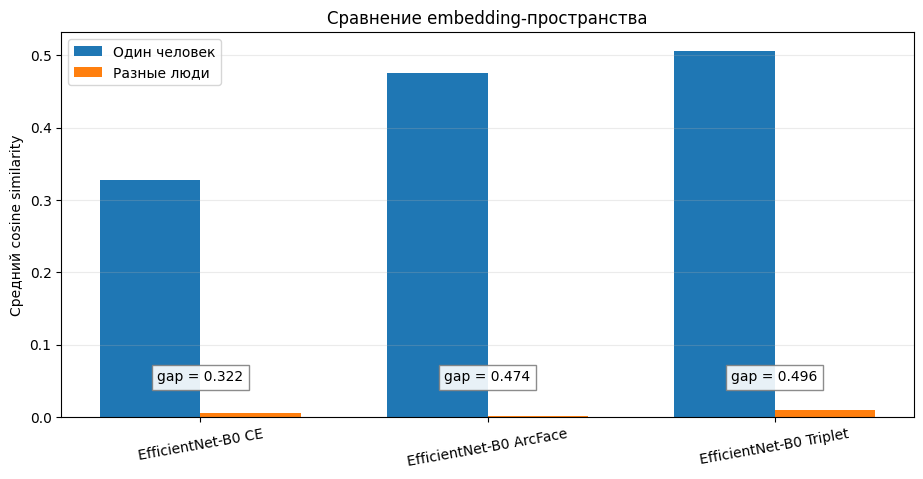

In [56]:
x = np.arange(len(quality_df))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(x - width / 2, quality_df["same_person_cosine"], width, label="Один человек")

plt.bar(x + width / 2, quality_df["different_people_cosine"], width, label="Разные люди")

plt.xticks(x, quality_df["model"], rotation=10)
plt.ylabel("Средний cosine similarity")
plt.title("Сравнение embedding-пространства")
plt.grid(axis="y", alpha=0.25)
plt.legend()

for i, row in quality_df.iterrows():
    plt.text(i, 0.05, f"gap = {row['gap']:.3f}", ha="center", bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))

plt.show()

## Косинусное расстояние

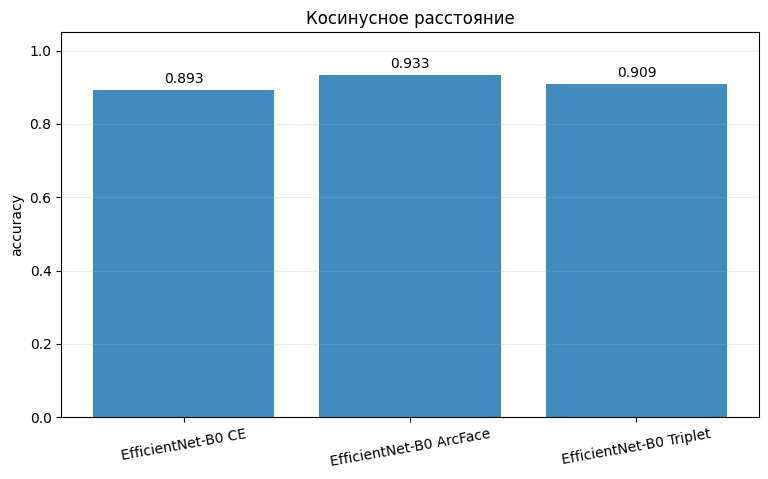

In [58]:
plt.figure(figsize=(9, 5))
plt.bar(quality_df["model"], quality_df["verification_accuracy"], alpha=0.85)

plt.ylim(0, 1.05)
plt.ylabel("accuracy")
plt.title("Косинусное расстояние")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=10)

for i, value in enumerate(quality_df["verification_accuracy"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.show()

# Вывод

Для дополнительного эксперимента была реализована модель, обучаемая с помощью Triplet Loss. В отличие от CrossEntropy и ArcFace, Triplet Loss не использует классификационный слой, а напрямую оптимизирует расстояния между embeddings. На каждой итерации модель получает тройку изображений: anchor, positive и negative. Positive соответствует тому же человеку, что и anchor, а negative — другому человеку.

В качестве расстояния использовался косинусное расстояние (cosine distance). Для контроля качества вместо classification accuracy использовались triplet accuracy и метрики embedding-пространства: средний cosine similarity для пар одного человека, средний cosine similarity для пар разных людей и gap между ними.

Triplet Loss увеличил разрыв между сходством фотографий одного человека и разных людей. Это означает, что embedding-пространство стало лучше подходить для face verification.